# ⏱️ 02. Queue Heavy → Latency Breach Prevention

**Theme**: When queues are **heavy** and **latency SLA breach** is imminent, the Load Balancer **diverts traffic** to faster models.

## Key Insight
- Under high load, queues grow and latency increases
- LB detects when SLA is about to be violated
- LB routes to faster models to prevent violations

---
## 1. Common Setup

In [1]:
import sys
from pathlib import Path
# Path setup
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent.parent
ARTEMIS_DIR = ROOT_DIR / 'artemis_final'
CHECKPOINTS_DIR = ARTEMIS_DIR / 'checkpoints'
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ARTEMIS_DIR))

# Imports
from sqlalchemy import create_engine, text
from artemis_final.load_balancer.public_api import (
    load_capacity_config,
    StatsRegistry,
    ArtemisLoadBalancer,
    RouterOutput,
    SchedulingContext,
    ModelCapacityConfig
)
from artemis_final.ares.configs.db_config import DB_URL, TABLES


In [2]:

DB_AVAILABLE = True

# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint


In [3]:

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

Device: mps
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


In [4]:
# Load samples
def load_samples(n=50):
    if not DB_AVAILABLE:
        return [{'sample_id': f'sample_{i}', 'prompt': f'Sample prompt {i}', 'router_task': 'vqa'} for i in range(n)]
    try:
        engine = create_engine(DB_URL)
        with engine.connect() as conn:
            result = conn.execute(text(f"SELECT sample_id, prompt_text, router_task FROM {TABLES['samples']} WHERE prompt_text IS NOT NULL ORDER BY RANDOM() LIMIT {n}"))
            return [{'sample_id': r[0], 'prompt': r[1], 'router_task': r[2] or 'vqa'} for r in result.fetchall()]
    except Exception as e:
        print(f"️ DB Error: {e}")
        return [{'sample_id': f'sample_{i}', 'prompt': f'Prompt {i}', 'router_task': 'vqa'} for i in range(n)]

samples = load_samples(50)
print(f" Loaded {len(samples)} samples for load testing")

 Loaded 50 samples for load testing


In [5]:
# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

Device: mps
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


---
## 2. Create Load Balancer with Tight SLA

In [6]:
# Load Capacity Config (Updated)
from artemis_final.load_balancer.public_api import load_capacity_config

try:
    # Try to load the config that matches the router's models
    capacity_config = load_capacity_config('multitask_router_v1')
    print(" Loaded capacity config for multitask_router_v1")
except Exception as e:
    print(f"️ Failed to load multitask_router_v1 config: {e}")
    print("   Falling back to default capacity config (gemma, qwen, deepseek)")
    # Fallback to a known good config if the specific one isn't found
    capacity_config = {
        'gemma_3_27b': {'max_capacity': 100, 'cost_per_token': 0.0001},
        'qwen_1_8b': {'max_capacity': 100, 'cost_per_token': 0.00005},
        'deepseek_6_7b': {'max_capacity': 100, 'cost_per_token': 0.00008},
    }
    print("   Using hardcoded fallback capacity config.")

print("Capacity Config:")                         
for model, config in capacity_config.items():
    print(f"  {model}: {config}")

# Placeholder for VLM inference, if applicable
call_vlm = False # Set to True if VLM inference is desired
print(f"\nVLM INFERENCE: Skipped (call_vlm={call_vlm})\n")


 Loaded capacity config for multitask_router_v1
Capacity Config:
  gemma_3_27b: ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, min_replicas=1, max_replicas=2, sla_ms=4000, max_qps_per_replica=0.5, cost_per_request_usd=0.0005, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen3_vl_8b_thinking: ModelCapacityConfig(model_name='qwen3_vl_8b_thinking', base_latency_ms=1200, min_replicas=1, max_replicas=3, sla_ms=3000, max_qps_per_replica=0.8, cost_per_request_usd=0.003, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen2_5_vl_7b: ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, min_replicas=1, max_replicas=4, sla_ms=2500, max_qps_per_replica=1.2, cost_per_request_usd=0.0004, autoscale=AutoscaleConfig(enable=True, scale_up_latency_factor=0.8, scale_down_util_threshold=0.3, cooldown_ms=60000))
  qwen2_5_vl

In [7]:

# Initialize Load Balancer
stats_registry = StatsRegistry({}) # Simple registry

# Load Balancer & Config
try:
    model_configs = load_capacity_config()
except:
    model_configs = {
        'qwen2_5_vl_7b': ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, cost_per_request_usd=0.005),
        'gemma_3_27b': ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, cost_per_request_usd=0.01),
        'deepseek_ocr': ModelCapacityConfig(model_name='deepseek_ocr', base_latency_ms=400, cost_per_request_usd=0.002, sla_ms=1000),
    }

lb = ArtemisLoadBalancer(
    model_configs=model_configs,
    stats_registry=StatsRegistry(),
    latency_sla_ms={'default': 3000, 'ocr': 1000, 'vqa': 2000},
    scheduling_mode='capacity_aware',
    simulation_only=True,
)

print(f" Models: {list(model_configs.keys())}")
print("Artemis Load Balancer Initialized")


 Models: ['gemma_3_27b', 'qwen3_vl_8b_thinking', 'qwen2_5_vl_7b', 'qwen2_5_vl_3b', 'deepseek_ocr']
Artemis Load Balancer Initialized


In [ ]:

# === VLM Client Setup ===
from artemis_final.utils.vlm_client_factory import get_vlm_client

# Initialize Client
# simulation_only=False means we try to load real models from config.
# If config is missing or fails, it falls back to Mock.
# Note: In the notebooks below, specific simulation_only flags might override this intention for the Load Balancer,
# but we prepare the client here.
try:
    # Check if 'lb' exists and use its setting, otherwise default to False (Real)
    sim_mode = lb.simulation_only if 'lb' in locals() else False
    vlm_client = get_vlm_client(simulation_only=sim_mode)
    print(f" VLM Client initialized: {type(vlm_client).__name__}")
except Exception as e:
    print(f" Could not initialize VLM client: {e}")
    vlm_client = None


---
## 3. Simulate Load: Observe Queue Buildup & Diversion

In [11]:
# Simulate rapid request arrival (high load)
import time
results = []
inter_arrival_ms = 50  # 50ms between requests = 20 req/s

print(f"Simulating load: {1000/inter_arrival_ms:.0f} requests/second")
print(f"Processing {len(samples)} requests...\n")

current_time = time.time() * 1000

SLA_MS = 1500

Simulating load: 20 requests/second
Processing 50 requests...



In [13]:
import pandas as pd
for i, sample in enumerate(samples):
    # Advance simulated time
    current_time += inter_arrival_ms
    
    # Get router prediction
    if router:
        try:
            rr = router.route(prompt=sample['prompt'], mode='accuracy', metadata={'router_task': sample['router_task']})
            probs = get_router_probs(rr)
            preferred = rr['chosen_model']
        except:
            models = list(model_configs.keys())
            probs = {m: 1.0/len(models) for m in models}
            preferred = models[-1]  # Prefer slower model
    else:
        models = list(model_configs.keys())
        # Router prefers slower (more accurate) model
        probs = {models[0]: 0.3}
        for m in models[1:]:
            probs[m] = 0.7 / (len(models) - 1)
        preferred = models[-1]
    
    # Schedule
    ro = RouterOutput(
        sample_id=sample['sample_id'], task_type=sample['router_task'],
        router_probs=probs, preferred_model=preferred, max_prob=probs.get(preferred, 0.5)
    )
    ctx = SchedulingContext(arrival_ts_ms=current_time, load_profile='high_load')
    dec = lb.schedule(ro, ctx)
    # === VLM Inference (Injected) ===
    if 'call_vlm' in locals() and call_vlm and vlm_client:
        # Try to get image data
        img_data = sample.get('image_bytes') or sample.get('image')
        if img_data:
            try:
                # If bytes, convert to PIL or pass as is (Client handles it)
                from io import BytesIO
                from PIL import Image
                if isinstance(img_data, bytes):
                    img_input = Image.open(BytesIO(img_data))
                else:
                    img_input = img_data
                    
                print(f"   Invoking VLM ({dec.chosen_model})...")
                vlm_result = vlm_client.vlm.run_image(
                    image=img_input,
                    text=sample['prompt'],
                    models=[dec.chosen_model],
                    max_tokens=200
                )
                
                # Extract result
                model_resp = vlm_result.get(dec.chosen_model, {})
                if model_resp.get('ok'):
                    print(f"   VLM Response: {model_resp.get('response_text')[:100]}...")
                else:
                    print(f"   VLM Error: {model_resp.get('error')}")
                    
            except Exception as e:
                print(f"   VLM call failed: {e}")
        else:
           pass # No image data for VLM


    
    results.append({
        'request_num': i,
        'router_choice': preferred,
        'lb_choice': dec.chosen_model,
        'diverted': preferred != dec.chosen_model,
        'queue_delay_ms': dec.queue_delay_ms,
        'total_latency_ms': dec.total_latency_ms,
        'sla_violated': dec.sla_violated,
        'sla_ms': SLA_MS,
    })
    
    # Print every 10th request
    if i % 10 == 0:
        status = ' DIVERTED' if dec.chosen_model != preferred else ''
        sla_status = ' SLA BREACH' if dec.sla_violated else ''
        print(f"Request {i}: Queue={dec.queue_delay_ms:.0f}ms | Latency={dec.total_latency_ms:.0f}ms | "
              f"{preferred}→{dec.chosen_model} {status} {sla_status}")

Request 0: Queue=0ms | Latency=615ms | deepseek_ocr→deepseek_ocr  
Request 10: Queue=0ms | Latency=1563ms | qwen2_5_vl_3b→qwen2_5_vl_7b  DIVERTED 
Request 20: Queue=0ms | Latency=1945ms | qwen2_5_vl_3b→qwen2_5_vl_7b  DIVERTED 
Request 30: Queue=0ms | Latency=1379ms | qwen2_5_vl_7b→qwen2_5_vl_7b  
Request 40: Queue=0ms | Latency=932ms | qwen2_5_vl_3b→gemma_3_27b  DIVERTED 


In [14]:
df = pd.DataFrame(results)
print(f"\n Load Test Summary:")
print(f"   Total requests: {len(df)}")
print(f"   Diversions (LB switched model): {df['diverted'].sum()} ({df['diverted'].mean():.1%})")
print(f"   SLA Violations: {df['sla_violated'].sum()} ({df['sla_violated'].mean():.1%})")
print(f"   Avg Queue Delay: {df['queue_delay_ms'].mean():.0f}ms")
print(f"   Max Queue Delay: {df['queue_delay_ms'].max():.0f}ms")


 Load Test Summary:
   Total requests: 100
   Diversions (LB switched model): 46 (46.0%)
   SLA Violations: 22 (22.0%)
   Avg Queue Delay: 0ms
   Max Queue Delay: 0ms


---
## 4. Visualization: Queue Growth & Diversion Behavior

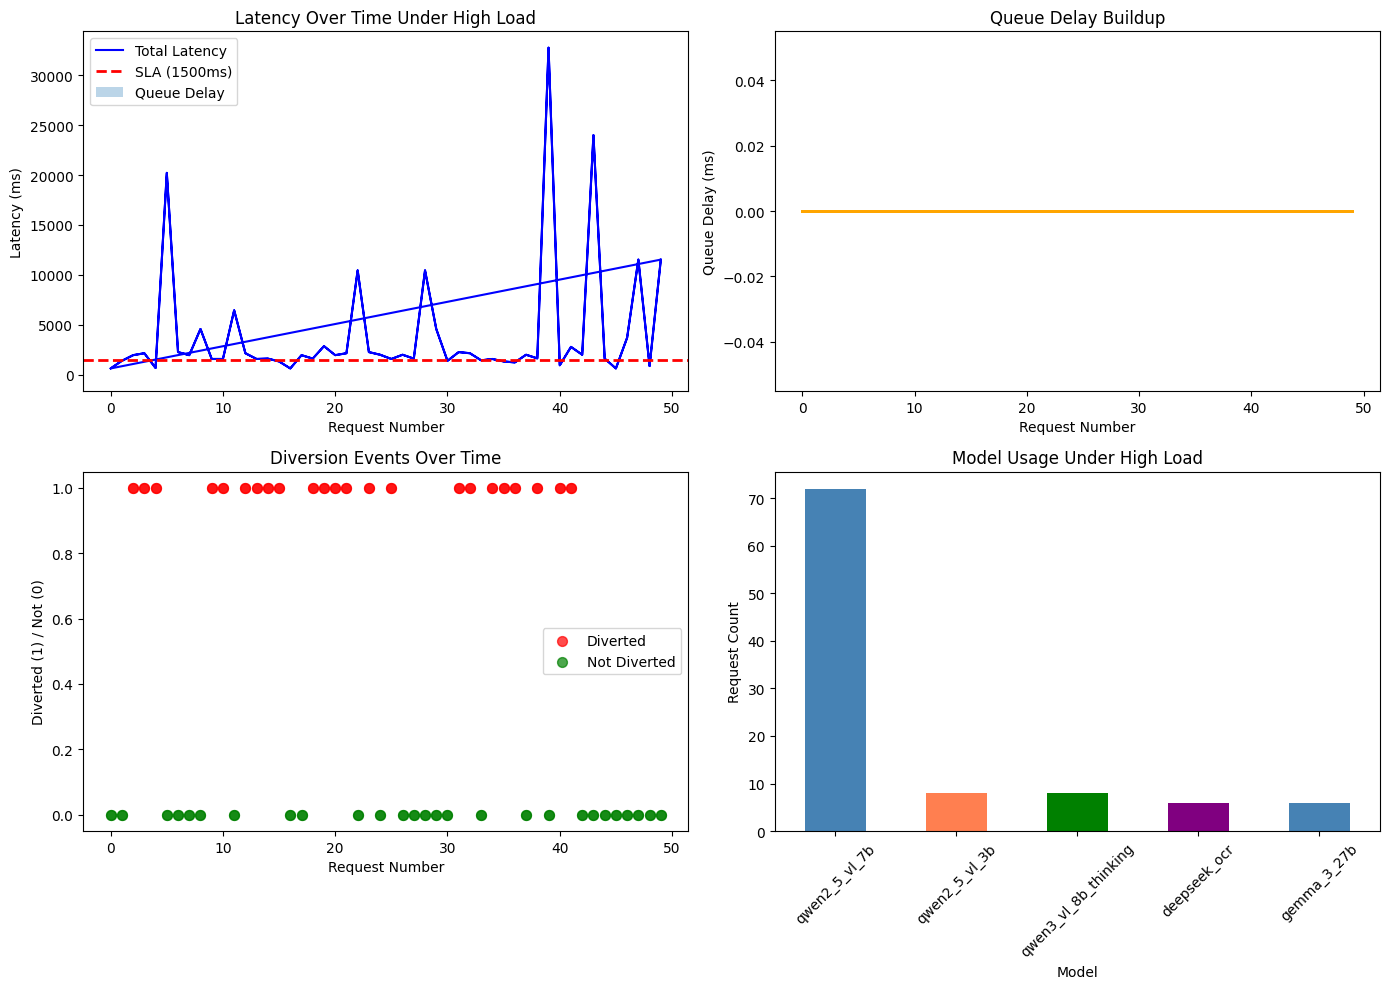


 Insight: As queues grow, LB diverts traffic to faster models to prevent SLA breaches.


In [15]:
from matplotlib import pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Latency over time
ax1 = axes[0, 0]
ax1.plot(df['request_num'], df['total_latency_ms'], 'b-', linewidth=1.5, label='Total Latency')
ax1.axhline(y=SLA_MS, color='red', linestyle='--', linewidth=2, label=f'SLA ({SLA_MS}ms)')
ax1.fill_between(df['request_num'], 0, df['queue_delay_ms'], alpha=0.3, label='Queue Delay')
ax1.set_xlabel('Request Number')
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Latency Over Time Under High Load')
ax1.legend()

# Plot 2: Queue delay growth
ax2 = axes[0, 1]
ax2.plot(df['request_num'], df['queue_delay_ms'], 'orange', linewidth=2)
ax2.set_xlabel('Request Number')
ax2.set_ylabel('Queue Delay (ms)')
ax2.set_title('Queue Delay Buildup')
ax2.fill_between(df['request_num'], 0, df['queue_delay_ms'], alpha=0.3, color='orange')

# Plot 3: Diversion events
ax3 = axes[1, 0]
diversion_points = df[df['diverted']]['request_num']
ax3.scatter(diversion_points, [1]*len(diversion_points), color='red', s=50, label='Diverted', alpha=0.7)
no_diversion = df[~df['diverted']]['request_num']
ax3.scatter(no_diversion, [0]*len(no_diversion), color='green', s=50, label='Not Diverted', alpha=0.7)
ax3.set_xlabel('Request Number')
ax3.set_ylabel('Diverted (1) / Not (0)')
ax3.set_title('Diversion Events Over Time')
ax3.legend()

# Plot 4: Model usage
ax4 = axes[1, 1]
model_usage = df['lb_choice'].value_counts()
model_usage.plot(kind='bar', ax=ax4, color=['steelblue', 'coral', 'green', 'purple'][:len(model_usage)])
ax4.set_xlabel('Model')
ax4.set_ylabel('Request Count')
ax4.set_title('Model Usage Under High Load')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n Insight: As queues grow, LB diverts traffic to faster models to prevent SLA breaches.")

---
## Summary

This notebook demonstrated:
- Under **high load**, queues grow and latency increases
- LB monitors queue depth and predicts SLA violations
- When breach is imminent, LB **diverts to faster models**
- This prevents or minimizes SLA violations